# Stage 1: Quadrant Detection

This notebook runs the first stage of the pipeline: detecting which dental quadrant an X-ray belongs to. We load the trained YOLO model, sanity-check its predictions on the test set, then generate a training report.

Four functions do the heavy lifting here. `smart_predict` and `compare_best_vs_last` come from `src/model_utils.py`. `generate_report` comes from `src/generate_report.py`, and `on_fit_epoch_end` comes from `src/model_callbacks.py`.

In [ ]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')
# add the project root to the path so the src package can be imported
sys.path.append(os.path.abspath('..'))

import yaml
from ultralytics import YOLO
from src.model_utils import smart_predict,compare_best_vs_last

%matplotlib inline

Patience Limit Is 10 Loaded Successfuly from the config file!


## Load configs

We'll pull in the stage 1 config, plus the YOLO data yaml it references. The next few cells just print each one out for a quick look.

In [ ]:
with open('../configs/stage1.yaml','r') as f:

    stage1_config = yaml.safe_load(f)

# this path comes from inside stage1_config, so stage1 has to load first
with open(stage1_config['model_args']['data'],'r') as f:

    quad_data_yaml = yaml.safe_load(f)

with open('../configs/trained_models.yaml','r') as f:

    trained_models_config = yaml.safe_load(f)

In [ ]:
stage1_config

{'paths': {'original_images_path': '../Data/Raw/DENTEX CHALLENGE 2023/Training_data/quadrant/xrays',
  'original_json_path': '../Data/Raw/DENTEX CHALLENGE 2023/Training_data/quadrant/train_quadrant.json',
  's1_main_path': '..\\Data\\Processed\\Stage 1 (Quadrant Detection)',
  'runs_s1_output': '..\\Runs\\Stage 1'},
 'model_args': {'data': '..\\Data\\Processed\\Stage 1 (Quadrant Detection)\\data.yaml',
  'model': '../Models/yolo26s.pt',
  'epochs': 50,
  'save': True,
  'imgsz': 1024,
  'batch': 8,
  'patience': 10,
  'optimizer': 'AdamW',
  'lr0': 0.001,
  'lrf': 0.01,
  'plots': True,
  'verbose': True,
  'device': 'cuda',
  'workers': 4,
  'project': 'Runs',
  'name': 'Stage 1',
  'save_dir': '..\\Runs\\Stage 1',
  'auto_augment': 'None',
  'augment': True,
  'mosaic': 0.0,
  'mixup': 0.0,
  'copy_paste': 0.0,
  'cutmix': 0.0,
  'hsv_h': 0.015,
  'hsv_s': 0.4,
  'hsv_v': 0.4,
  'degrees': 5.0,
  'translate': 0.05,
  'scale': 0.1,
  'shear': 0.0,
  'perspective': 0.0,
  'flipud': 0.0

In [ ]:
quad_data_yaml

{'train': 'C:\\Users\\ibrah.HIMA\\OneDrive\\Desktop\\Full AI\\Projects\\GitHub - Kaggle Projects\\dental-xray-ai\\Data\\Processed\\Stage 1 (Quadrant Detection)\\train\\images',
 'val': 'C:\\Users\\ibrah.HIMA\\OneDrive\\Desktop\\Full AI\\Projects\\GitHub - Kaggle Projects\\dental-xray-ai\\Data\\Processed\\Stage 1 (Quadrant Detection)\\valid\\images',
 'test': 'C:\\Users\\ibrah.HIMA\\OneDrive\\Desktop\\Full AI\\Projects\\GitHub - Kaggle Projects\\dental-xray-ai\\Data\\Processed\\Stage 1 (Quadrant Detection)\\test\\images',
 'nc': 4,
 'names': ['Upper Right', 'Upper Left', 'Lower Left', 'Lower Right']}

In [ ]:
trained_models_config

{'quadrant_detection_model': {'best': '..\\Runs\\Stage 1\\weights\\best.pt',
  'last': '..\\Runs\\Stage 1\\weights\\last.pt'},
 'enumeration_detection_model': {'best': '..\\Runs\\Stage 2\\weights\\best.pt',
  'last': '..\\Runs\\Stage 2\\weights\\last.pt'},
 'disease_classification_model': {'best': '..\\Runs\\Stage 3\\weights\\best.pt',
  'last': '..\\Runs\\Stage 3\\weights\\last.pt'}}

## Load the quadrant detection model

We start from the base YOLO checkpoint, then load the weights from the last training run. Training already happened, so the training call below stays commented out for reference.

In [ ]:
# load the base checkpoint specified in the config, this is the starting point before training
yolo_model = YOLO(stage1_config['model_args']['model'])

In [ ]:
# training already ran once; left here commented out for reference
# yolo_model.train(**stage1_config['model_args'])

In [ ]:
# compare the best vs last checkpoint on the enumeration task using the test split
results = compare_best_vs_last(quad_data_yaml,trained_models_config,
                                stage='quad', split_name = 'test',
                                original_images_path=stage1_config['paths']['original_images_path'],
                                annotations_df_path=os.path.join(stage1_config['paths']['s2_main_path'], 'test_df (splitted).pkl'),
                                results_csv_path= os.path.join(stage1_config['paths']['runs_s2_output'], 'results.csv'))


Comparison: Best Epoch vs Last Epoch
Best Epoch (42):
  mAP50: 0.9950
  mAP50-95: 0.7286
Last Epoch (51):
  mAP50: 0.9950
  mAP50-95: 0.7209
Verdict (based on training metrics only):
Best Epoch (42) is better than Last Epoch (51).
Difference in mAP50-95: +0.0078
This gap can indicate some overfitting toward the end of training.

Running best and last weights on the test set
quadrant_detection_model - best


Cropping using trained quadrant model: 100%|██████████| 70/70 [00:09<00:00,  7.25it/s]


  duplicates: 3, low_confidence: 2, missing: 2, successful: 278, avg_conf: 0.9765
quadrant_detection_model - last


Cropping using trained quadrant model: 100%|██████████| 70/70 [00:09<00:00,  7.51it/s]

  duplicates: 2, low_confidence: 2, missing: 1, successful: 279, avg_conf: 0.9784

Test set summary
quadrant_detection_model_best: total_errors=7, avg_confidence=0.9765
quadrant_detection_model_last: total_errors=5, avg_confidence=0.9784

Lowest total errors on test set: quadrant_detection_model_last with 5 errors


In [ ]:
# load the checkpoint saved at the end of training, this is the model we'll actually use for inference
quadrant_model_detection = YOLO(trained_models_config['quad_detection_model']['last'])

## Sanity-check predictions

Before running this model across the whole dataset, let's look at what it predicts on the test set. We'll call `smart_predict` a few times: first plain, then saving the annotated output, then saving cropped quadrants, then comparing against the ground-truth boxes with two different drawing styles.


image 1/1 C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Data\Processed\Stage 1 (Quadrant Detection)\test\images\train_293.png: 512x1024 1 Upper Right, 1 Upper Left, 1 Lower Left, 1 Lower Right, 38.2ms
Speed: 4.3ms preprocess, 38.2ms inference, 0.7ms postprocess per image at shape (1, 3, 512, 1024)
Class Name: Lower Right
Coordinates: [546.8342895507812, 649.4340209960938, 1404.1544189453125, 1101.309814453125]
Confidence: %99.0
Class Name: Upper Right
Coordinates: [593.7418212890625, 297.1649169921875, 1401.1514892578125, 722.9442138671875]
Confidence: %99.0
Class Name: Lower Left
Coordinates: [1394.2191162109375, 677.2001953125, 2192.0322265625, 1108.495849609375]
Confidence: %99.0
Class Name: Upper Left
Coordinates: [1386.4678955078125, 329.2877197265625, 2184.933349609375, 736.3510131835938]
Confidence: %99.0


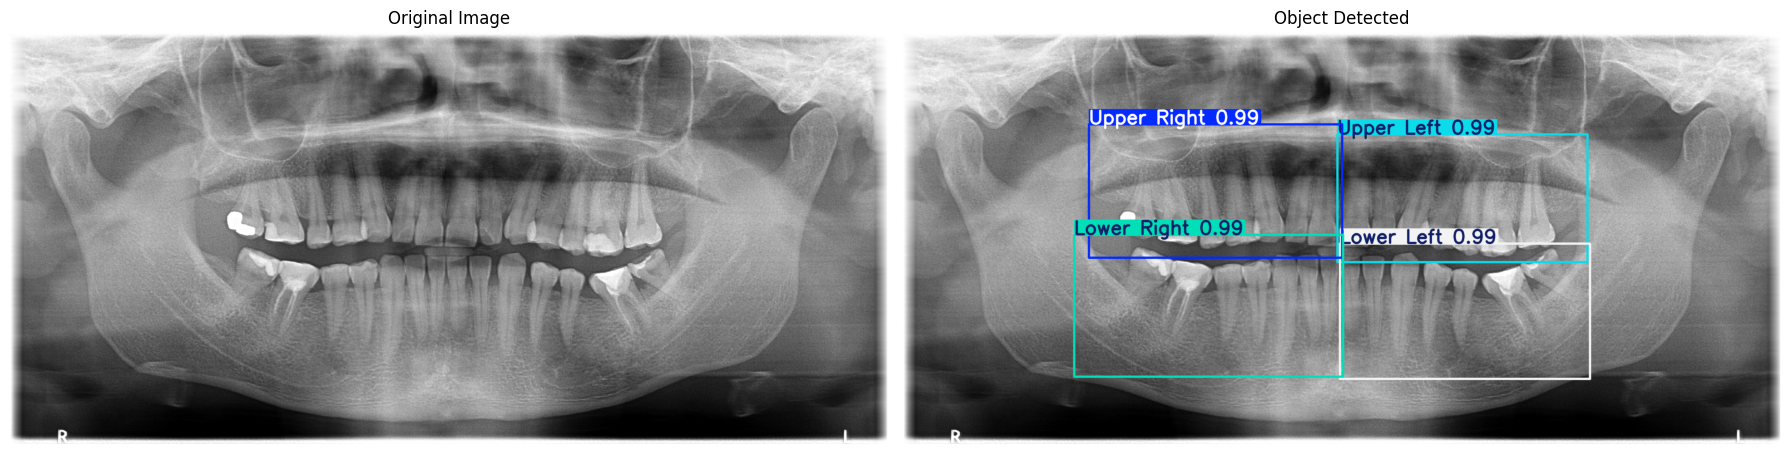

In [ ]:
# run with default settings first, just to confirm the model loads and predicts fine
smart_predict(quadrant_model_detection,quad_data_yaml['test'])


image 1/1 C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Data\Processed\Stage 1 (Quadrant Detection)\test\images\train_284.png: 480x1024 1 Upper Right, 1 Upper Left, 1 Lower Left, 1 Lower Right, 97.1ms
Speed: 14.3ms preprocess, 97.1ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 1024)
Class Name: Upper Left
Coordinates: [1485.734375, 302.140625, 2095.41357421875, 736.197998046875]
Confidence: %99.0
Class Name: Upper Right
Coordinates: [868.2702026367188, 333.8301696777344, 1499.2813720703125, 745.1804809570312]
Confidence: %99.0
Class Name: Lower Right
Coordinates: [770.37548828125, 606.5411987304688, 1521.9359130859375, 1098.299072265625]
Confidence: %99.0
Class Name: Lower Left
Coordinates: [1480.9169921875, 575.22314453125, 2227.69775390625, 1089.81103515625]
Confidence: %98.0


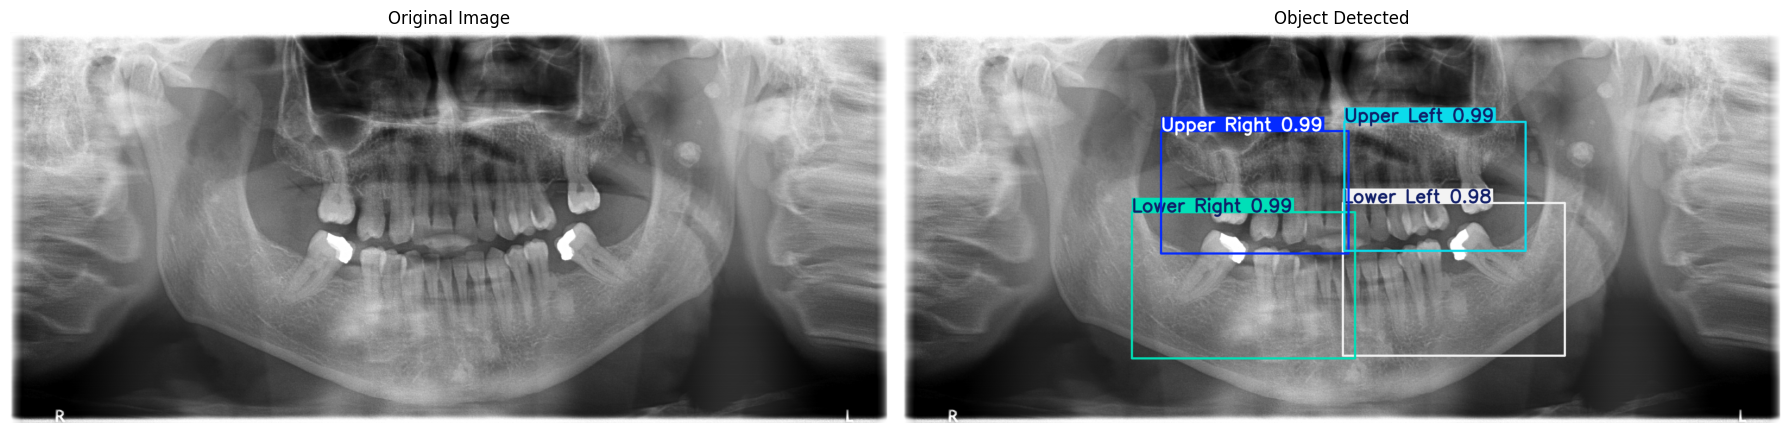

In [ ]:
# same predictions, but save the annotated output images this time
smart_predict(quadrant_model_detection,quad_data_yaml['test'],save_output=True,save_dir=os.path.join(stage1_config['paths']['runs_s1_output'],'Test Outputs Predictions'))


image 1/1 C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Data\Processed\Stage 1 (Quadrant Detection)\test\images\train_241.png: 512x1024 1 Upper Right, 1 Upper Left, 1 Lower Left, 1 Lower Right, 89.8ms
Speed: 5.4ms preprocess, 89.8ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 1024)
Class Name: Lower Left
Coordinates: [1379.4638671875, 573.2013549804688, 2201.747802734375, 1074.2203369140625]
Confidence: %99.0
Class Name: Upper Right
Coordinates: [627.5994873046875, 267.8916931152344, 1382.2191162109375, 672.7194213867188]
Confidence: %99.0
Class Name: Upper Left
Coordinates: [1380.779296875, 255.97640991210938, 2154.52685546875, 675.162353515625]
Confidence: %99.0
Class Name: Lower Right
Coordinates: [569.7120361328125, 573.7730102539062, 1392.9342041015625, 1073.19921875]
Confidence: %98.0


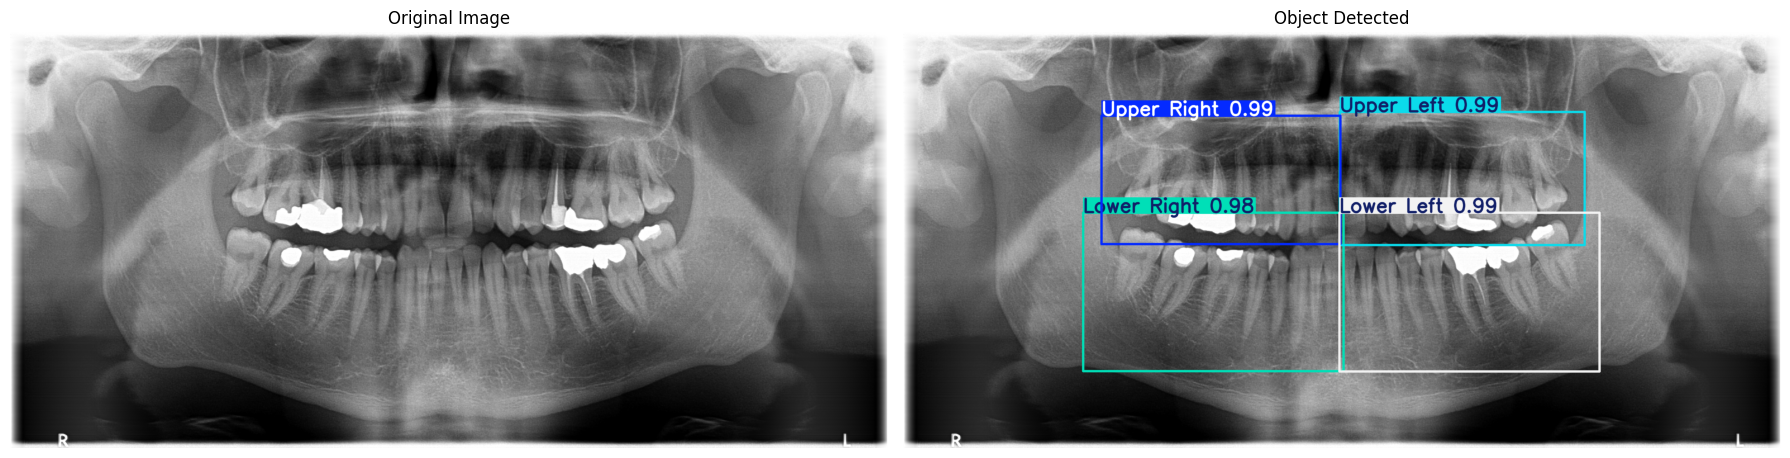

In [ ]:
# save the cropped quadrant images instead of full annotated frames
smart_predict(quadrant_model_detection,quad_data_yaml['test'],save_crop_output_image=True,save_dir=os.path.join(stage1_config['paths']['runs_s1_output'],'Test Outputs Predictions'))


image 1/1 C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Data\Processed\Stage 1 (Quadrant Detection)\test\images\train_512.png: 384x768 1 Upper Right, 1 Upper Left, 1 Lower Left, 1 Lower Right, 75.2ms
Speed: 7.3ms preprocess, 75.2ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 768)
Class Name: Upper Right
Coordinates: [582.27734375, 248.68914794921875, 1371.7080078125, 676.1416625976562]
Confidence: %98.0
Class Name: Lower Right
Coordinates: [515.4501342773438, 559.4495849609375, 1348.3294677734375, 1087.950439453125]
Confidence: %98.0
Class Name: Upper Left
Coordinates: [1356.430419921875, 175.21043395996094, 2185.748779296875, 668.7935180664062]
Confidence: %97.0
Class Name: Lower Left
Coordinates: [1330.3450927734375, 538.5769653320312, 2163.968017578125, 1084.993408203125]
Confidence: %97.0


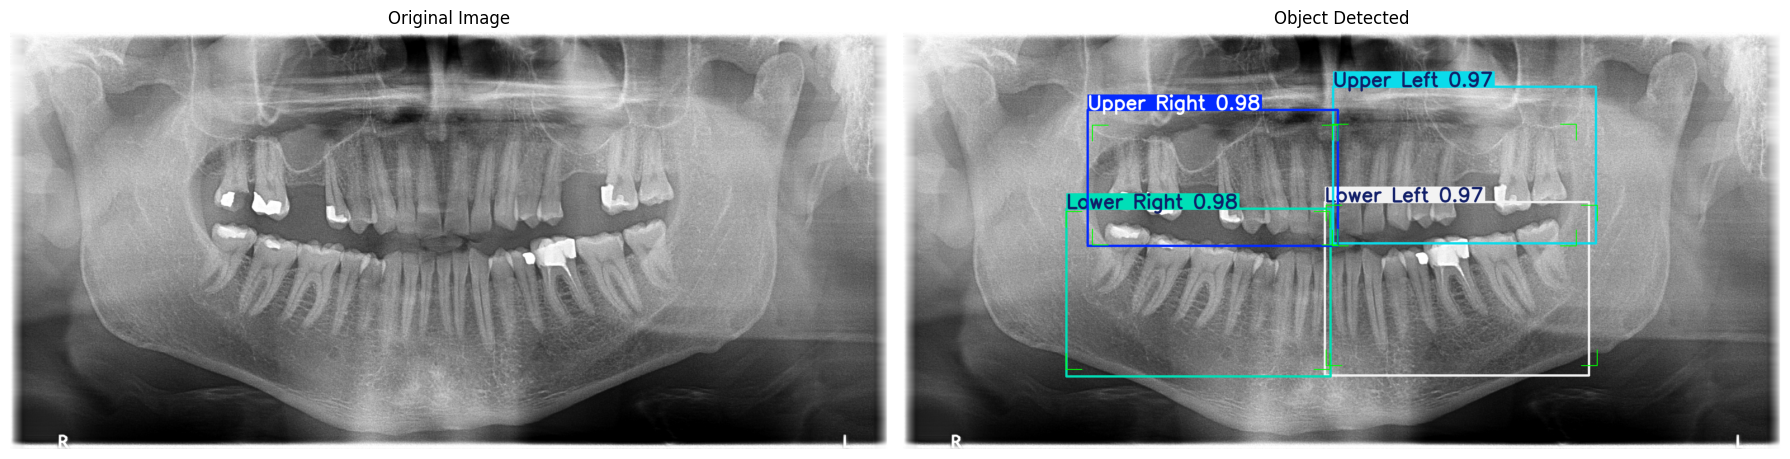

In [ ]:
# overlay the ground-truth boxes next to the predictions for a visual comparison
smart_predict(quadrant_model_detection,quad_data_yaml['test'],show_true_boxes=True)


image 1/1 C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Data\Processed\Stage 1 (Quadrant Detection)\test\images\train_493.png: 480x1024 1 Upper Right, 1 Upper Left, 1 Lower Left, 1 Lower Right, 95.3ms
Speed: 7.9ms preprocess, 95.3ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 1024)
Class Name: Lower Right
Coordinates: [634.0875854492188, 574.842529296875, 1472.606201171875, 1079.396240234375]
Confidence: %99.0
Class Name: Lower Left
Coordinates: [1454.69921875, 603.5469360351562, 2256.822998046875, 1064.6751708984375]
Confidence: %99.0
Class Name: Upper Left
Coordinates: [1466.49853515625, 370.89208984375, 2166.14013671875, 759.9698486328125]
Confidence: %99.0
Class Name: Upper Right
Coordinates: [740.5459594726562, 350.83770751953125, 1471.6507568359375, 768.4490966796875]
Confidence: %99.0


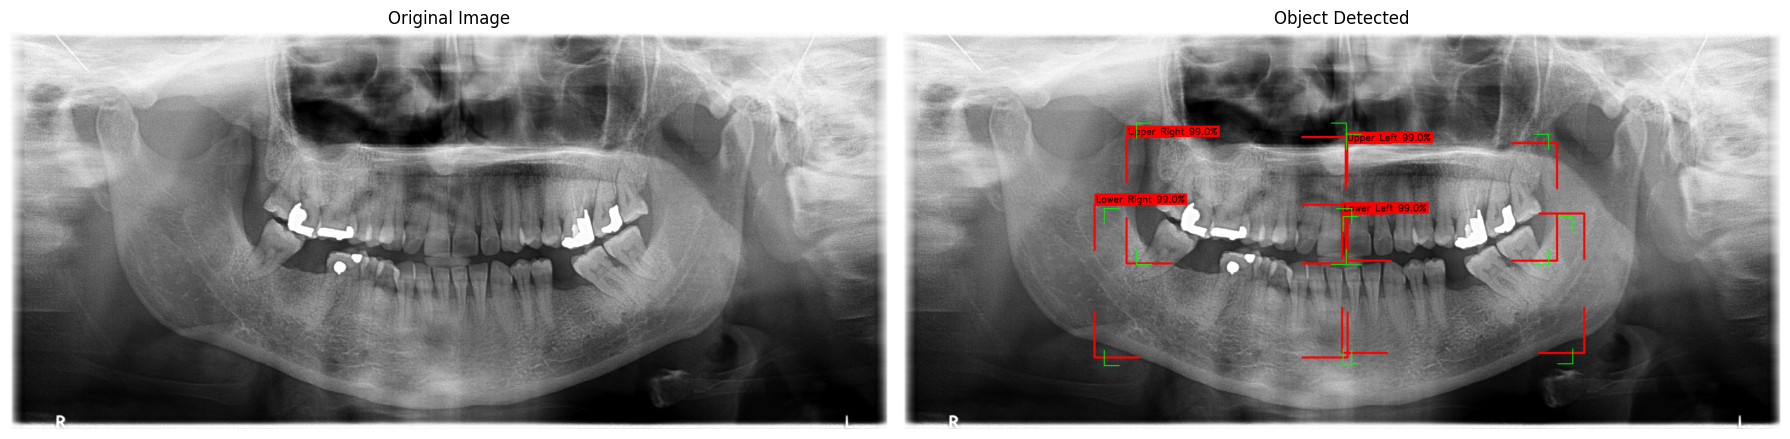

In [ ]:
# same comparison, but using the custom box-drawing style instead of the default one
smart_predict(quadrant_model_detection,quad_data_yaml['test'],show_true_boxes=True,apply_custom_draw_box=True)